 # 02 — FPCA vs FPLS on L2-normalised sampled spectra



 This notebook compares two functional dimension-reduction strategies

 on the same sampled Gaia XP spectra:



 - FPCA = unsupervised functional projection

 - FPLS = supervised functional projection



 The goal here is not to compare against non-functional outside baselines,

 but to compare FPCA and FPLS fairly across several classifier families.



 Data:



 - calibrated flux from xp_sampled_spectra.csv

 - labels aligned via og_xp.csv

 - no XP coefficients used as features



 Classifiers:



 - Centroid

 - kNN

 - weighted kNN

 - Logistic Regression

 - linear SVM



 Outputs:



 - fpca_vs_fpls_classifier_rskf_metrics.csv

 - fpca_vs_fpls_classifier_summary.csv

 - fpca_vs_fpls_best_by_representation.csv

 - fpca_vs_fpls_best_by_classifier.csv

 - fpca_vs_fpls_pretty_table.csv

In [1]:
from __future__ import annotations

import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

J_VALUES = [1, 2, 3, 5, 10, 15]
K_KNN = 5


 ## 1. Paths and configuration

In [ ]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "final_functional"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_CANDIDATES = [
    BASE_DIR / "og_xp.csv",
]

SAMPLED_CANDIDATES = [
    BASE_DIR / "xp_sampled_spectra.csv",
]

SPLITS_CANDIDATES = [
    BASE_DIR / "splits_rskf.json",
]

NOTEBOOK_NAME = "02_fpca_vs_fpls"
SMOKE = False


 ## 2. File helpers

In [3]:
def find_first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


def split_sort_key(k: str):
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return (rep, fold)


def fmt_ms(series):
    m = series.mean()
    s = series.std(ddof=1) if len(series) > 1 else 0.0
    return f"{m:.4f} ± {s:.4f}"


def ms(mean, std):
    if pd.isna(mean):
        return np.nan
    return f"{mean:.4f} ± {0.0 if pd.isna(std) else std:.4f}"


 ## 3. Load sampled spectra and labels

In [4]:
og_path = find_first_existing(LABEL_CANDIDATES)
spec_path = find_first_existing(SAMPLED_CANDIDATES)
split_path = find_first_existing(SPLITS_CANDIDATES)

if og_path is None:
    raise FileNotFoundError(
        f"Could not find og_xp file. Checked: {[str(p) for p in LABEL_CANDIDATES]}"
    )

if spec_path is None:
    raise FileNotFoundError(
        f"Could not find sampled spectra file. Checked: {[str(p) for p in SAMPLED_CANDIDATES]}"
    )

if split_path is None:
    raise FileNotFoundError(
        f"Could not find splits_rskf.json. Checked: {[str(p) for p in SPLITS_CANDIDATES]}"
    )

print("Using label file:", og_path.resolve())
print("Using sampled spectra file:", spec_path.resolve())
print("Using split file:", split_path.resolve())

df_og = pd.read_csv(og_path)
df_spec = pd.read_csv(spec_path)

if "source_id" not in df_og.columns or "y" not in df_og.columns:
    raise ValueError("Label file must contain 'source_id' and 'y'.")

if "source_id" not in df_spec.columns:
    raise ValueError("Sampled spectra file must contain 'source_id'.")

wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]
if len(wl_cols) == 0:
    raise ValueError("No wavelength columns found. Expected columns starting with 'wl_'.")

wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols], dtype=np.float64)

df_m = df_og[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols],
    on="source_id",
    how="inner",
    validate="one_to_one",
)

assert len(df_m) == len(df_og) == len(df_spec), "Row alignment failed"

y = df_m["y"].to_numpy(dtype=np.int64)
F_raw = df_m[wl_cols].to_numpy(dtype=np.float64)

n, p = F_raw.shape
print(f"N = {n}, p = {p} (wavelength bins)")
print(
    f"Class balance: non-binary={int((y == 0).sum())}, binary={int((y == 1).sum())} "
    f"({(y == 1).mean():.1%} positive)"
)


Using label file: C:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\og_xp.csv
Using sampled spectra file: C:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\xp_sampled_spectra.csv
Using split file: C:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\splits_rskf.json
N = 2815, p = 343 (wavelength bins)
Class balance: non-binary=2257, binary=558 (19.8% positive)


 ## 4. L2 normalisation

In [5]:
norms = np.linalg.norm(F_raw, axis=1, keepdims=True)
norms = np.maximum(norms, 1e-15)
F = F_raw / norms


 ## 5. Quick diagnostics

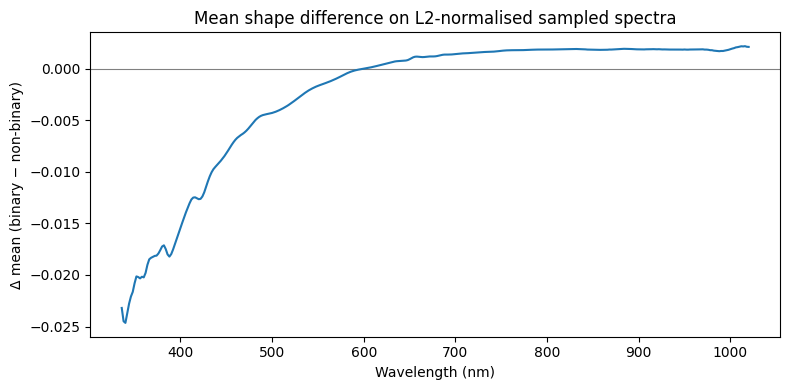

In [6]:
mu0 = F[y == 0].mean(axis=0)
mu1 = F[y == 1].mean(axis=0)
delta = mu1 - mu0

plt.figure(figsize=(8, 4))
plt.axhline(0, color="gray", lw=0.8)
plt.plot(wavelengths, delta, lw=1.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Δ mean (binary − non-binary)")
plt.title("Mean shape difference on L2-normalised sampled spectra")
plt.tight_layout()
plt.show()
plt.close()


 ## 6. Load predefined repeated stratified splits

In [7]:
with open(split_path) as f:
    splits = json.load(f)

if SMOKE:
    splits = {k: v for k, v in splits.items() if k.startswith("rep0_")}
    print(f"SMOKE mode: using {len(splits)} splits")
else:
    print(f"Full mode: using {len(splits)} splits")

split_names = sorted(splits.keys(), key=split_sort_key)
print(f"Loaded {len(split_names)} splits")


Full mode: using 50 splits
Loaded 50 splits


 ## 7. Helper functions

In [8]:
def normalize_scores_train_ref(scores_te: np.ndarray, scores_tr: np.ndarray) -> np.ndarray:
    lo, hi = float(scores_tr.min()), float(scores_tr.max())
    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)
    out = ((scores_te - lo) / (hi - lo)).astype(np.float64)
    return np.clip(out, 0.0, 1.0)


def pick_youden_threshold(y_true: np.ndarray, y_prob: np.ndarray, grid_size: int = 200) -> float:
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1.0, 0.5

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)

    return best_thr


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
):
    out = {"pr_auc": average_precision_score(y_true_te, y_score_te)}

    try:
        out["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        out["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)
    thr = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= thr).astype(np.int64)

    out["youden_threshold"] = thr
    out["sensitivity"] = recall_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["precision"] = precision_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["specificity"] = recall_score(y_true_te, y_pred, pos_label=0, zero_division=0)
    out["accuracy"] = accuracy_score(y_true_te, y_pred)
    out["f1"] = f1_score(y_true_te, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    out["youden_j"] = sens + spec - 1.0

    return out


def projection_fpca(F_tr_c, F_te_c, J):
    pca = PCA(n_components=J, random_state=RANDOM_STATE)
    xi_tr = pca.fit_transform(F_tr_c)
    xi_te = pca.transform(F_te_c)
    return xi_tr, xi_te


def projection_fpls(F_tr_c, F_te_c, y_tr, J):
    pls = PLSRegression(n_components=J)
    pls.fit(F_tr_c, y_tr)
    xi_tr = pls.transform(F_tr_c)
    xi_te = pls.transform(F_te_c)
    return xi_tr, xi_te


def centroid_scores(xi_tr, y_tr, xi_te):
    mu_b = xi_tr[y_tr == 1].mean(axis=0)
    mu_s = xi_tr[y_tr == 0].mean(axis=0)
    # larger score => closer to binary centroid
    return np.sum((xi_te - mu_s) ** 2, axis=1) - np.sum((xi_te - mu_b) ** 2, axis=1)


def knn_scores(xi_tr, y_tr, xi_te, k=5, weighted=False):
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(xi_tr)

    d_te, idx_te = nn.kneighbors(xi_te)
    y_nn_te = y_tr[idx_te]

    if weighted:
        w_te = 1.0 / np.maximum(d_te, 1e-12)
        score_te = (w_te * y_nn_te).sum(axis=1) / w_te.sum(axis=1)
    else:
        score_te = y_nn_te.mean(axis=1)

    # train scores without self-neighbour
    nn_tr = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn_tr.fit(xi_tr)
    d_tr, idx_tr = nn_tr.kneighbors(xi_tr)

    d_tr = d_tr[:, 1:]
    idx_tr = idx_tr[:, 1:]
    y_nn_tr = y_tr[idx_tr]

    if weighted:
        w_tr = 1.0 / np.maximum(d_tr, 1e-12)
        score_tr = (w_tr * y_nn_tr).sum(axis=1) / w_tr.sum(axis=1)
    else:
        score_tr = y_nn_tr.mean(axis=1)

    return score_tr.astype(np.float64), score_te.astype(np.float64)


def summarise_run(df_run: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    metric_cols = [
        "pr_auc", "roc_auc", "sensitivity", "precision", "specificity",
        "accuracy", "f1", "youden_j", "youden_threshold"
    ]

    agg_dict = {}
    for m in metric_cols:
        agg_dict[f"{m}_mean"] = pd.NamedAgg(column=m, aggfunc="mean")
        agg_dict[f"{m}_std"] = pd.NamedAgg(column=m, aggfunc="std")

    return df_run.groupby(group_cols).agg(**agg_dict).reset_index()


 ## 8. Run FPCA and FPLS experiments across classifier families

In [9]:
CLASSIFIERS = [
    "centroid",
    "knn",
    "weighted_knn",
    "lr",
    "linear_svm",
]

records = []

print(f"--- Starting evaluation for {len(split_names)} splits ---")

for sname in split_names:
    print(f"\nProcessing split: {sname}")

    tr_idx = np.array(splits[sname]["train"], dtype=int)
    te_idx = np.array(splits[sname]["test"], dtype=int)

    F_tr = F[tr_idx]
    F_te = F[te_idx]
    y_tr = y[tr_idx]
    y_te = y[te_idx]

    mu_train = F_tr.mean(axis=0)
    F_tr_c = F_tr - mu_train
    F_te_c = F_te - mu_train

    max_allowed_j = min(F_tr_c.shape[0] - 1, F_tr_c.shape[1])

    for J in J_VALUES:
        if J > max_allowed_j:
            continue

        print(f"  > J={J}: FPCA + FPLS")

        for method_family in ["FPCA", "FPLS"]:
            if method_family == "FPCA":
                xi_tr, xi_te = projection_fpca(F_tr_c, F_te_c, J)
            else:
                xi_tr, xi_te = projection_fpls(F_tr_c, F_te_c, y_tr, J)

            # 1. Centroid
            sc_tr = centroid_scores(xi_tr, y_tr, xi_tr)
            sc_te = centroid_scores(xi_tr, y_tr, xi_te)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append(
                {
                    "split": sname,
                    "method_family": method_family,
                    "J": J,
                    "classifier": "centroid",
                    **met,
                }
            )

            # 2. kNN
            sc_tr, sc_te = knn_scores(xi_tr, y_tr, xi_te, k=K_KNN, weighted=False)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append(
                {
                    "split": sname,
                    "method_family": method_family,
                    "J": J,
                    "classifier": "knn",
                    **met,
                }
            )

            # 3. weighted kNN
            sc_tr, sc_te = knn_scores(xi_tr, y_tr, xi_te, k=K_KNN, weighted=True)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append(
                {
                    "split": sname,
                    "method_family": method_family,
                    "J": J,
                    "classifier": "weighted_knn",
                    **met,
                }
            )

            # 4. Logistic Regression
            lr = LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            )
            lr.fit(xi_tr, y_tr)
            sc_tr = lr.decision_function(xi_tr)
            sc_te = lr.decision_function(xi_te)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append(
                {
                    "split": sname,
                    "method_family": method_family,
                    "J": J,
                    "classifier": "lr",
                    **met,
                }
            )

            # 5. Linear SVM
            svm = LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            )
            svm.fit(xi_tr, y_tr)
            sc_tr = svm.decision_function(xi_tr)
            sc_te = svm.decision_function(xi_te)
            met = fold_metrics(y_te, sc_te, y_tr, sc_tr)
            records.append(
                {
                    "split": sname,
                    "method_family": method_family,
                    "J": J,
                    "classifier": "linear_svm",
                    **met,
                }
            )

print("\n--- All evaluations finished ---")
df_run = pd.DataFrame(records)
print(df_run.head())


--- Starting evaluation for 50 splits ---

Processing split: rep0_fold0
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold1
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold2
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold3
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep0_fold4
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processing split: rep1_fold0
  > J=1: FPCA + FPLS
  > J=2: FPCA + FPLS
  > J=3: FPCA + FPLS
  > J=5: FPCA + FPLS
  > J=10: FPCA + FPLS
  > J=15: FPCA + FPLS

Processin

 ## 9. Save per-fold metrics

In [21]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

metrics_path = OUT_DIR / f"{NOTEBOOK_NAME}_classifier_rskf_metrics_{timestamp}.csv"
df_run.to_csv(metrics_path, index=False)
print("Saved", metrics_path)


Saved c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\02_fpca_vs_fpls_classifier_rskf_metrics_20260409_2038.csv


 ## 10. Summary table

In [22]:
df_agg = summarise_run(df_run, ["method_family", "J", "classifier"])

summary_path = OUT_DIR / f"{NOTEBOOK_NAME}_classifier_summary_{timestamp}.csv"
df_agg.to_csv(summary_path, index=False)
print("Saved", summary_path)


Saved c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\02_fpca_vs_fpls_classifier_summary_20260409_2038.csv


 ## 11. PR-AUC and F1 vs J

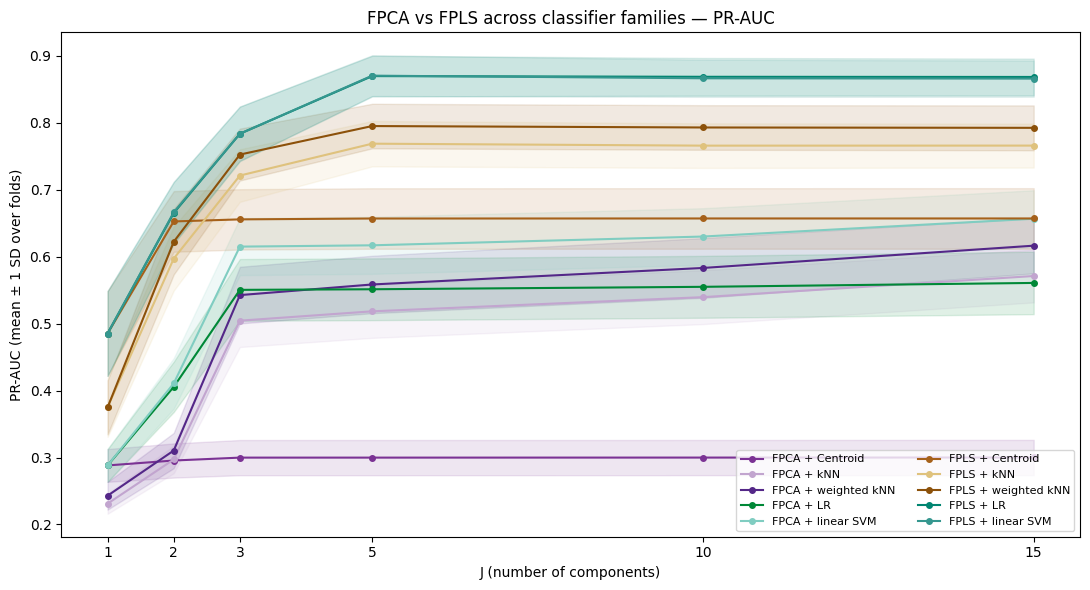

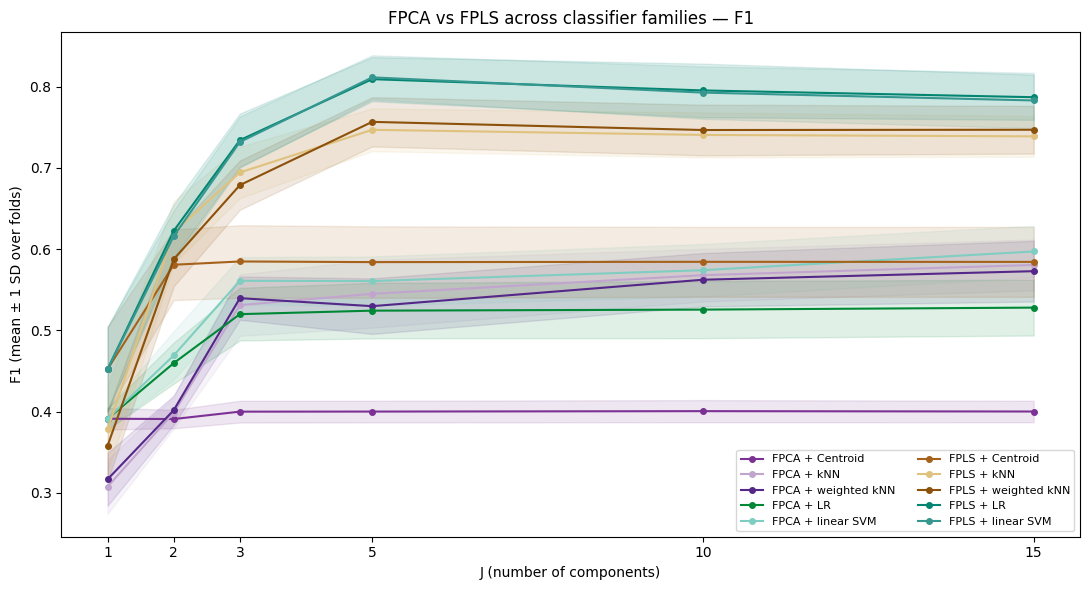

In [23]:
colors = {
    ("FPCA", "centroid"): "#7b3294",
    ("FPCA", "knn"): "#c2a5cf",
    ("FPCA", "weighted_knn"): "#542788",
    ("FPCA", "lr"): "#008837",
    ("FPCA", "linear_svm"): "#80cdc1",
    ("FPLS", "centroid"): "#a6611a",
    ("FPLS", "knn"): "#dfc27d",
    ("FPLS", "weighted_knn"): "#8c510a",
    ("FPLS", "lr"): "#018571",
    ("FPLS", "linear_svm"): "#35978f",
}

labels_plot = {
    ("FPCA", "centroid"): "FPCA + Centroid",
    ("FPCA", "knn"): "FPCA + kNN",
    ("FPCA", "weighted_knn"): "FPCA + weighted kNN",
    ("FPCA", "lr"): "FPCA + LR",
    ("FPCA", "linear_svm"): "FPCA + linear SVM",
    ("FPLS", "centroid"): "FPLS + Centroid",
    ("FPLS", "knn"): "FPLS + kNN",
    ("FPLS", "weighted_knn"): "FPLS + weighted kNN",
    ("FPLS", "lr"): "FPLS + LR",
    ("FPLS", "linear_svm"): "FPLS + linear SVM",
}


def plot_metric_vs_J(metric_key: str, ylabel: str, title: str):
    plt.figure(figsize=(11, 6))

    for family in ["FPCA", "FPLS"]:
        for clf in CLASSIFIERS:
            sub = df_run[
                (df_run["method_family"] == family) &
                (df_run["classifier"] == clf)
            ]
            pivot_m = sub.groupby("J")[metric_key].mean().reindex(J_VALUES)
            pivot_s = sub.groupby("J")[metric_key].std().reindex(J_VALUES)

            m = pivot_m.values
            s = pivot_s.values

            plt.plot(
                J_VALUES,
                m,
                "o-",
                color=colors[(family, clf)],
                label=labels_plot[(family, clf)],
                ms=4,
            )
            plt.fill_between(
                J_VALUES,
                m - s,
                m + s,
                color=colors[(family, clf)],
                alpha=0.12,
            )

    plt.xlabel("J (number of components)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(J_VALUES)
    plt.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
    plt.close()


plot_metric_vs_J(
    "pr_auc",
    "PR-AUC (mean ± 1 SD over folds)",
    "FPCA vs FPLS across classifier families — PR-AUC",
)

plot_metric_vs_J(
    "f1",
    "F1 (mean ± 1 SD over folds)",
    "FPCA vs FPLS across classifier families — F1",
)


 ## 12. Best model by representation

In [24]:
best_by_representation = (
    df_agg.sort_values(["f1_mean", "pr_auc_mean"], ascending=False)
    .groupby("method_family", as_index=False)
    .first()
)

best_by_representation_pretty = pd.DataFrame({
    "Representation": best_by_representation["method_family"],
    "Best classifier": best_by_representation["classifier"],
    "Best J": best_by_representation["J"],
    "PR-AUC mean ± std": [
        ms(m, s) for m, s in zip(
            best_by_representation["pr_auc_mean"],
            best_by_representation["pr_auc_std"]
        )
    ],
    "ROC-AUC mean ± std": [
        ms(m, s) for m, s in zip(
            best_by_representation["roc_auc_mean"],
            best_by_representation["roc_auc_std"]
        )
    ],
    "F1 mean ± std": [
        ms(m, s) for m, s in zip(
            best_by_representation["f1_mean"],
            best_by_representation["f1_std"]
        )
    ],
})

print("\n=== BEST BY REPRESENTATION ===")
print(best_by_representation_pretty.to_string(index=False))

best_by_representation_path = OUT_DIR / f"{NOTEBOOK_NAME}_best_by_representation_{timestamp}.csv"
best_by_representation_pretty.to_csv(best_by_representation_path, index=False)
print("Saved", best_by_representation_path)



=== BEST BY REPRESENTATION ===
Representation Best classifier  Best J PR-AUC mean ± std ROC-AUC mean ± std   F1 mean ± std
          FPCA      linear_svm      15   0.6564 ± 0.0425    0.8527 ± 0.0190 0.5970 ± 0.0317
          FPLS      linear_svm       5   0.8700 ± 0.0304    0.9319 ± 0.0145 0.8113 ± 0.0272
Saved c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\02_fpca_vs_fpls_best_by_representation_20260409_2038.csv


 ## 13. Best model by classifier family

In [25]:
best_by_classifier = (
    df_agg.sort_values(["f1_mean", "pr_auc_mean"], ascending=False)
    .groupby("classifier", as_index=False)
    .first()
)

best_by_classifier_pretty = pd.DataFrame({
    "Classifier": best_by_classifier["classifier"],
    "Best representation": best_by_classifier["method_family"],
    "Best J": best_by_classifier["J"],
    "PR-AUC mean ± std": [
        ms(m, s) for m, s in zip(
            best_by_classifier["pr_auc_mean"],
            best_by_classifier["pr_auc_std"]
        )
    ],
    "ROC-AUC mean ± std": [
        ms(m, s) for m, s in zip(
            best_by_classifier["roc_auc_mean"],
            best_by_classifier["roc_auc_std"]
        )
    ],
    "F1 mean ± std": [
        ms(m, s) for m, s in zip(
            best_by_classifier["f1_mean"],
            best_by_classifier["f1_std"]
        )
    ],
})

print("\n=== BEST BY CLASSIFIER ===")
print(best_by_classifier_pretty.to_string(index=False))

best_by_classifier_path = OUT_DIR / f"{NOTEBOOK_NAME}_best_by_classifier_{timestamp}.csv"
best_by_classifier_pretty.to_csv(best_by_classifier_path, index=False)
print("Saved", best_by_classifier_path)



=== BEST BY CLASSIFIER ===
  Classifier Best representation  Best J PR-AUC mean ± std ROC-AUC mean ± std   F1 mean ± std
    centroid                FPLS       3   0.6555 ± 0.0450    0.8514 ± 0.0226 0.5847 ± 0.0446
         knn                FPLS       5   0.7685 ± 0.0339    0.8928 ± 0.0160 0.7467 ± 0.0263
  linear_svm                FPLS       5   0.8700 ± 0.0304    0.9319 ± 0.0145 0.8113 ± 0.0272
          lr                FPLS       5   0.8693 ± 0.0304    0.9319 ± 0.0145 0.8091 ± 0.0272
weighted_knn                FPLS       5   0.7948 ± 0.0332    0.8944 ± 0.0163 0.7565 ± 0.0303
Saved c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\final_functional\02_fpca_vs_fpls_best_by_classifier_20260409_2038.csv


 ## 14. Final pretty comparison table

In [26]:
df_pretty = pd.DataFrame({
    "Representation": df_agg["method_family"],
    "J": df_agg["J"],
    "Classifier": df_agg["classifier"],
    "PR-AUC mean ± std": [ms(m, s) for m, s in zip(df_agg["pr_auc_mean"], df_agg["pr_auc_std"])],
    "ROC-AUC mean ± std": [ms(m, s) for m, s in zip(df_agg["roc_auc_mean"], df_agg["roc_auc_std"])],
    "Sensitivity mean ± std": [ms(m, s) for m, s in zip(df_agg["sensitivity_mean"], df_agg["sensitivity_std"])],
    "Precision mean ± std": [ms(m, s) for m, s in zip(df_agg["precision_mean"], df_agg["precision_std"])],
    "Specificity mean ± std": [ms(m, s) for m, s in zip(df_agg["specificity_mean"], df_agg["specificity_std"])],
    "Accuracy mean ± std": [ms(m, s) for m, s in zip(df_agg["accuracy_mean"], df_agg["accuracy_std"])],
    "F1 mean ± std": [ms(m, s) for m, s in zip(df_agg["f1_mean"], df_agg["f1_std"])],
    "Youden J mean ± std": [ms(m, s) for m, s in zip(df_agg["youden_j_mean"], df_agg["youden_j_std"])],
})

df_pretty = df_pretty.sort_values(
    by=["Representation", "Classifier", "J"]
).reset_index(drop=True)

print("\n=== PRETTY COMPARISON TABLE ===")
print(df_pretty.to_string(index=False))

pretty_path = OUT_DIR / f"{NOTEBOOK_NAME}_pretty_table_{timestamp}.csv"
df_pretty.to_csv(pretty_path, index=False)
print("Saved", pretty_path)



=== PRETTY COMPARISON TABLE ===
Representation  J   Classifier PR-AUC mean ± std ROC-AUC mean ± std Sensitivity mean ± std Precision mean ± std Specificity mean ± std Accuracy mean ± std   F1 mean ± std Youden J mean ± std
          FPCA  1     centroid   0.2882 ± 0.0245    0.6310 ± 0.0227        0.8292 ± 0.0277      0.2560 ± 0.0095        0.4037 ± 0.0220     0.4880 ± 0.0182 0.3911 ± 0.0132     0.2329 ± 0.0341
          FPCA  2     centroid   0.2955 ± 0.0255    0.6419 ± 0.0242        0.8487 ± 0.0333      0.2539 ± 0.0080        0.3829 ± 0.0267     0.4752 ± 0.0189 0.3907 ± 0.0114     0.2316 ± 0.0296
          FPCA  3     centroid   0.2998 ± 0.0263    0.6495 ± 0.0239        0.8659 ± 0.0311      0.2600 ± 0.0093        0.3903 ± 0.0222     0.4845 ± 0.0180 0.3998 ± 0.0134     0.2562 ± 0.0352
          FPCA  5     centroid   0.2998 ± 0.0263    0.6495 ± 0.0239        0.8661 ± 0.0310      0.2600 ± 0.0093        0.3903 ± 0.0223     0.4847 ± 0.0180 0.3999 ± 0.0133     0.2565 ± 0.0350
          FP

 ## 15. Final ranking by F1 and PR-AUC

In [27]:
rank_by_f1 = df_agg.sort_values(
    ["f1_mean", "pr_auc_mean", "roc_auc_mean"],
    ascending=False
).reset_index(drop=True)

rank_by_pr_auc = df_agg.sort_values(
    ["pr_auc_mean", "f1_mean", "roc_auc_mean"],
    ascending=False
).reset_index(drop=True)

print("\n=== TOP 15 BY F1 ===")
print(
    rank_by_f1[
        ["method_family", "J", "classifier", "f1_mean", "pr_auc_mean", "roc_auc_mean"]
    ].head(15).to_string(index=False)
)

print("\n=== TOP 15 BY PR-AUC ===")
print(
    rank_by_pr_auc[
        ["method_family", "J", "classifier", "pr_auc_mean", "f1_mean", "roc_auc_mean"]
    ].head(15).to_string(index=False)
)



=== TOP 15 BY F1 ===
method_family  J   classifier  f1_mean  pr_auc_mean  roc_auc_mean
         FPLS  5   linear_svm 0.811313     0.870002      0.931923
         FPLS  5           lr 0.809099     0.869331      0.931900
         FPLS 10           lr 0.795228     0.868294      0.932527
         FPLS 10   linear_svm 0.792565     0.866064      0.931513
         FPLS 15           lr 0.786889     0.868051      0.934860
         FPLS 15   linear_svm 0.782889     0.865577      0.933985
         FPLS  5 weighted_knn 0.756538     0.794761      0.894396
         FPLS 15 weighted_knn 0.746835     0.792103      0.890981
         FPLS  5          knn 0.746743     0.768453      0.892848
         FPLS 10 weighted_knn 0.746497     0.792636      0.891980
         FPLS 10          knn 0.740460     0.765523      0.890210
         FPLS 15          knn 0.738698     0.765589      0.889390
         FPLS  3           lr 0.734032     0.783274      0.907228
         FPLS  3   linear_svm 0.731741     0.783244   

 ## 16. Best FPCA vs best FPLS

In [17]:
fpca_best = rank_by_f1[rank_by_f1["method_family"] == "FPCA"].head(1).copy()
fpls_best = rank_by_f1[rank_by_f1["method_family"] == "FPLS"].head(1).copy()

if len(fpca_best):
    print("\nBest FPCA:")
    print(
        fpca_best[
            ["method_family", "J", "classifier", "f1_mean", "pr_auc_mean", "roc_auc_mean"]
        ].to_string(index=False)
    )

if len(fpls_best):
    print("\nBest FPLS:")
    print(
        fpls_best[
            ["method_family", "J", "classifier", "f1_mean", "pr_auc_mean", "roc_auc_mean"]
        ].to_string(index=False)
    )



Best FPCA:
method_family  J classifier  f1_mean  pr_auc_mean  roc_auc_mean
         FPCA 15 linear_svm 0.597005     0.656393      0.852703

Best FPLS:
method_family  J classifier  f1_mean  pr_auc_mean  roc_auc_mean
         FPLS  5 linear_svm 0.811313     0.870002      0.931923


 ## 17. 2D visualisation of class separation for best FPCA and best FPLS settings

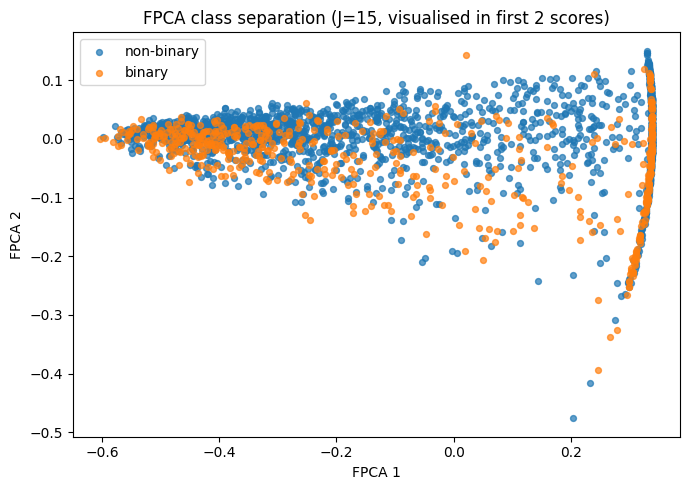

In [28]:
best_fpca_j = int(fpca_best.iloc[0]["J"]) if len(fpca_best) else 2
best_fpls_j = int(fpls_best.iloc[0]["J"]) if len(fpls_best) else 2

# use full dataset only for visualisation
F_centered = F - F.mean(axis=0)

# FPCA 2D
pca_vis = PCA(n_components=min(2, best_fpca_j), random_state=RANDOM_STATE)
fpca_scores_vis = pca_vis.fit_transform(F_centered)

plt.figure(figsize=(7, 5))
plt.scatter(fpca_scores_vis[y == 0, 0], fpca_scores_vis[y == 0, 1], s=18, alpha=0.7, label="non-binary")
plt.scatter(fpca_scores_vis[y == 1, 0], fpca_scores_vis[y == 1, 1], s=18, alpha=0.7, label="binary")
plt.xlabel("FPCA 1")
plt.ylabel("FPCA 2")
plt.title(f"FPCA class separation (J={best_fpca_j}, visualised in first 2 scores)")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_fpca_2d_visualisation_{timestamp}.png", dpi=300)
plt.close()


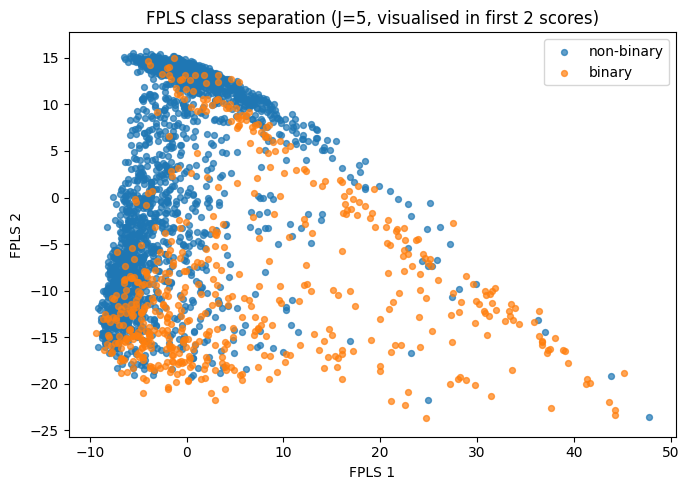

In [29]:
# FPLS 2D
pls_vis = PLSRegression(n_components=min(2, best_fpls_j))
fpls_scores_vis, _ = pls_vis.fit_transform(F_centered, y.astype(float).reshape(-1, 1))

plt.figure(figsize=(7, 5))
plt.scatter(fpls_scores_vis[y == 0, 0], fpls_scores_vis[y == 0, 1], s=18, alpha=0.7, label="non-binary")
plt.scatter(fpls_scores_vis[y == 1, 0], fpls_scores_vis[y == 1, 1], s=18, alpha=0.7, label="binary")
plt.xlabel("FPLS 1")
plt.ylabel("FPLS 2")
plt.title(f"FPLS class separation (J={best_fpls_j}, visualised in first 2 scores)")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(OUT_DIR / f"{NOTEBOOK_NAME}_fpls_2d_visualisation_{timestamp}.png", dpi=300)
plt.close()